In [1]:
from codebase.utils_ml import *

In [2]:
features_memmap = np.load('features_extracted_8_sim.npy', mmap_mode='r')
label_arr = np.array([np.tile(i,3000) for i in np.arange(0,8)]).flatten()

class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}


In [3]:
clf = CatBoostClassifier(
        verbose=100,  
        random_state=42,
        iterations=50         
        )
    
clf.fit(features_memmap, label_arr, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.5
0:	learn: 1.0815198	total: 403ms	remaining: 19.8s
49:	learn: 0.2244861	total: 18.1s	remaining: 0us


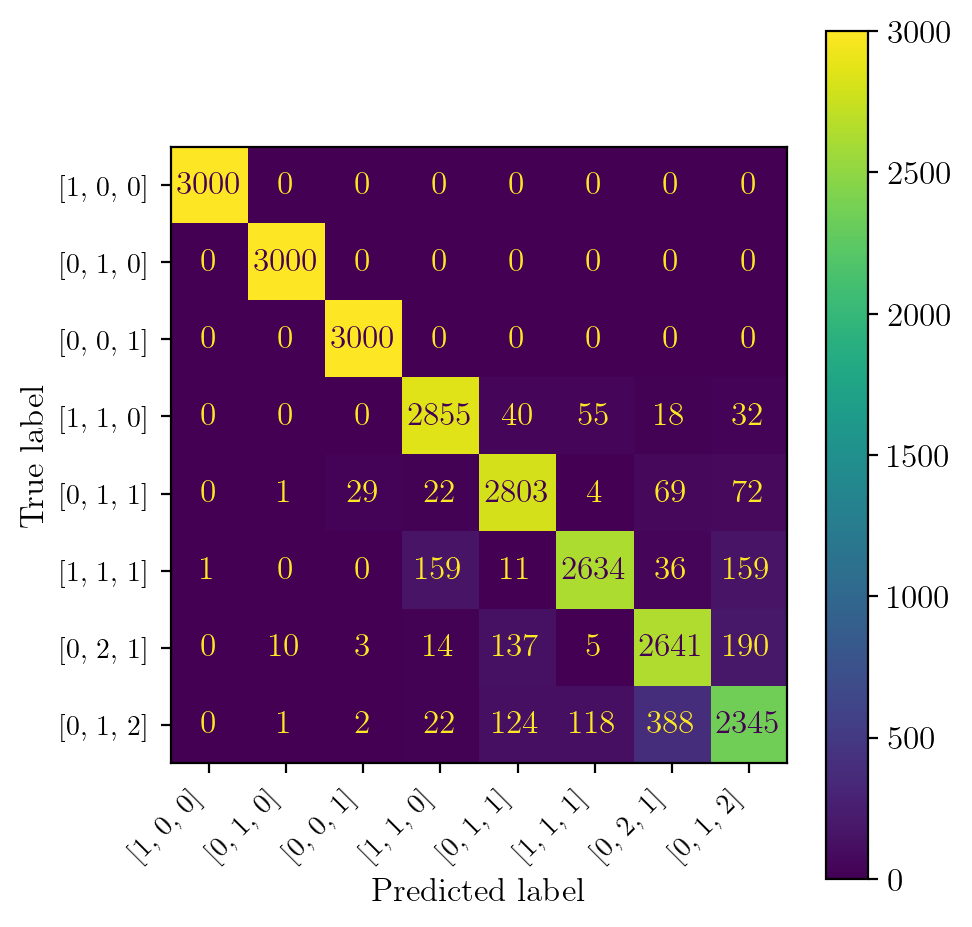

In [4]:
plot_cm(label_arr, clf.predict(features_memmap),class_to_poles)

(array([   0.,    0.,    0.,    0.,    0., 3000.,    0.,    0.,    0.,
           0.]),
 array([4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5]),
 <BarContainer object of 10 artists>)

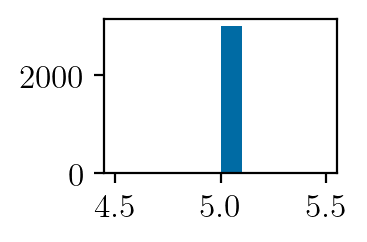

In [5]:
features_exp = np.load("features_extracted_8_exp.npy")
pred = clf.predict(features_exp)

fig, ax = plt.subplots(figsize=(1.5,1))
ax.hist(pred.flatten())